# Dreamer4 Tokenizer Feature Analysis
Single-task deep dive: encode expert trajectory frames with the tokenizer and analyze latent feature structure.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision.io import read_image
from pathlib import Path

sys.path.insert(0, "dreamer4")
from dreamer4.interactive import load_tokenizer_from_ckpt
from dreamer4.model import temporal_patchify, temporal_unpatchify

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

CKPT_PATH = "/Project/world_model/weights/tokenizer.pt"
DATA_DIR = "/Project/world_model/dreamer4/data/expert"
TASK = "pendulum-spin"  # change to any task in data/expert/
N_FRAMES = 40            # number of frames to analyze (None = all)

tok, info = load_tokenizer_from_ckpt(CKPT_PATH, device)
encoder, decoder = tok.encoder, tok.decoder
H, W, C, patch = info["H"], info["W"], info["C"], info["patch"]
print(f"Tokenizer loaded: {H}x{W}, patch={patch}, n_latents={info['n_latents']}, d_bottleneck={info['d_bottleneck']}")

Using device: cuda
Tokenizer loaded: 128x128, patch=4, n_latents=16, d_bottleneck=32


Loaded 10020 frames, shape: torch.Size([10020, 3, 128, 128])


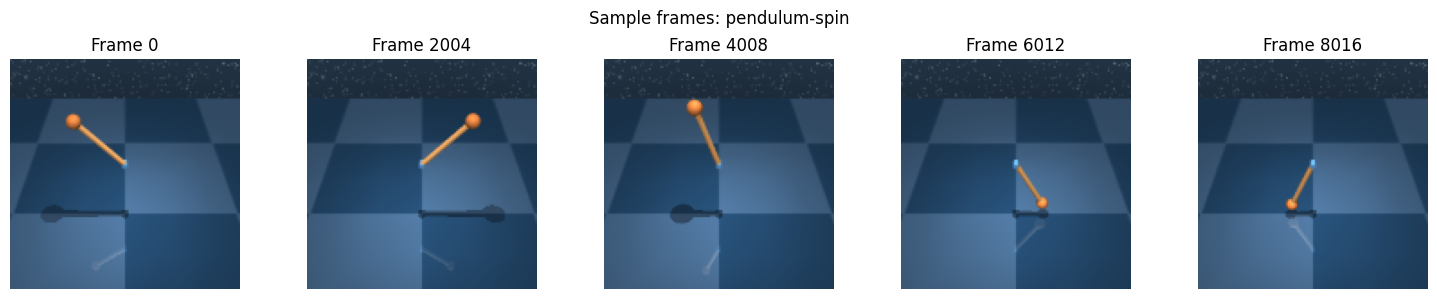

In [2]:
# Cell 2: Load raw frames from expert PNG filmstrips

def load_expert_frames(task: str, data_dir: str, target_size: int = 128):
    """Load all frames for a task from PNG filmstrips.
    Returns (N, 3, H, W) float tensor in [0,1]."""
    frames_list = []
    i = 0
    while True:
        path = os.path.join(data_dir, f"{task}-{i}.png")
        if not os.path.exists(path):
            break
        img = read_image(path)  # (3, 224, W_total) uint8
        c, h, w_total = img.shape
        assert h == 224 and w_total % 224 == 0, f"Unexpected shape {img.shape}"
        n_frames = w_total // 224
        # Split horizontally: (N, 3, 224, 224)
        frames = img.view(c, 224, n_frames, 224).permute(2, 0, 1, 3)
        frames_list.append(frames)
        i += 1
    all_frames = torch.cat(frames_list, 0)  # (total_N, 3, 224, 224)
    # Resize to model input size
    all_frames = F.interpolate(
        all_frames.float() / 255.0,
        size=(target_size, target_size),
        mode="bilinear", align_corners=False,
    )
    return all_frames

frames = load_expert_frames(TASK, DATA_DIR, target_size=H)
print(f"Loaded {frames.shape[0]} frames, shape: {frames.shape}")

# Show a few sample frames
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    idx = i * (len(frames) // 5)
    ax.imshow(frames[idx].permute(1, 2, 0).numpy())
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
plt.suptitle(f"Sample frames: {TASK}")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Load metadata, identify episode boundaries, trim to N_FRAMES

meta = torch.load(os.path.join(DATA_DIR, f"{TASK}.pt"), weights_only=False)
episodes = meta["episode"]   # (N,) int64
actions = meta["action"]     # (N, A) float32
rewards = meta["reward"]     # (N,) float32

print(f"Full dataset: {episodes.shape[0]} timesteps, {episodes.unique().shape[0]} episodes")

# Trim to first N_FRAMES
if N_FRAMES is not None and N_FRAMES < len(frames):
    frames = frames[:N_FRAMES]
    episodes = episodes[:N_FRAMES]
    actions = actions[:N_FRAMES]
    rewards = rewards[:N_FRAMES]
    print(f"Trimmed to first {N_FRAMES} frames")

assert frames.shape[0] == episodes.shape[0]

# Find episode boundaries within the trimmed range
unique_eps = episodes.unique(sorted=True)
ep_boundaries = []
for ep_id in unique_eps:
    mask = episodes == ep_id
    indices = mask.nonzero(as_tuple=True)[0]
    ep_boundaries.append((indices[0].item(), indices[-1].item() + 1))

print(f"Analyzing: {frames.shape[0]} frames, {len(ep_boundaries)} episodes")
print(f"Episode lengths: {[e-s for s, e in ep_boundaries]}")

Full dataset: 10020 timesteps, 20 episodes
Trimmed to first 40 frames
Analyzing: 40 frames, 1 episodes
Episode lengths: [40]


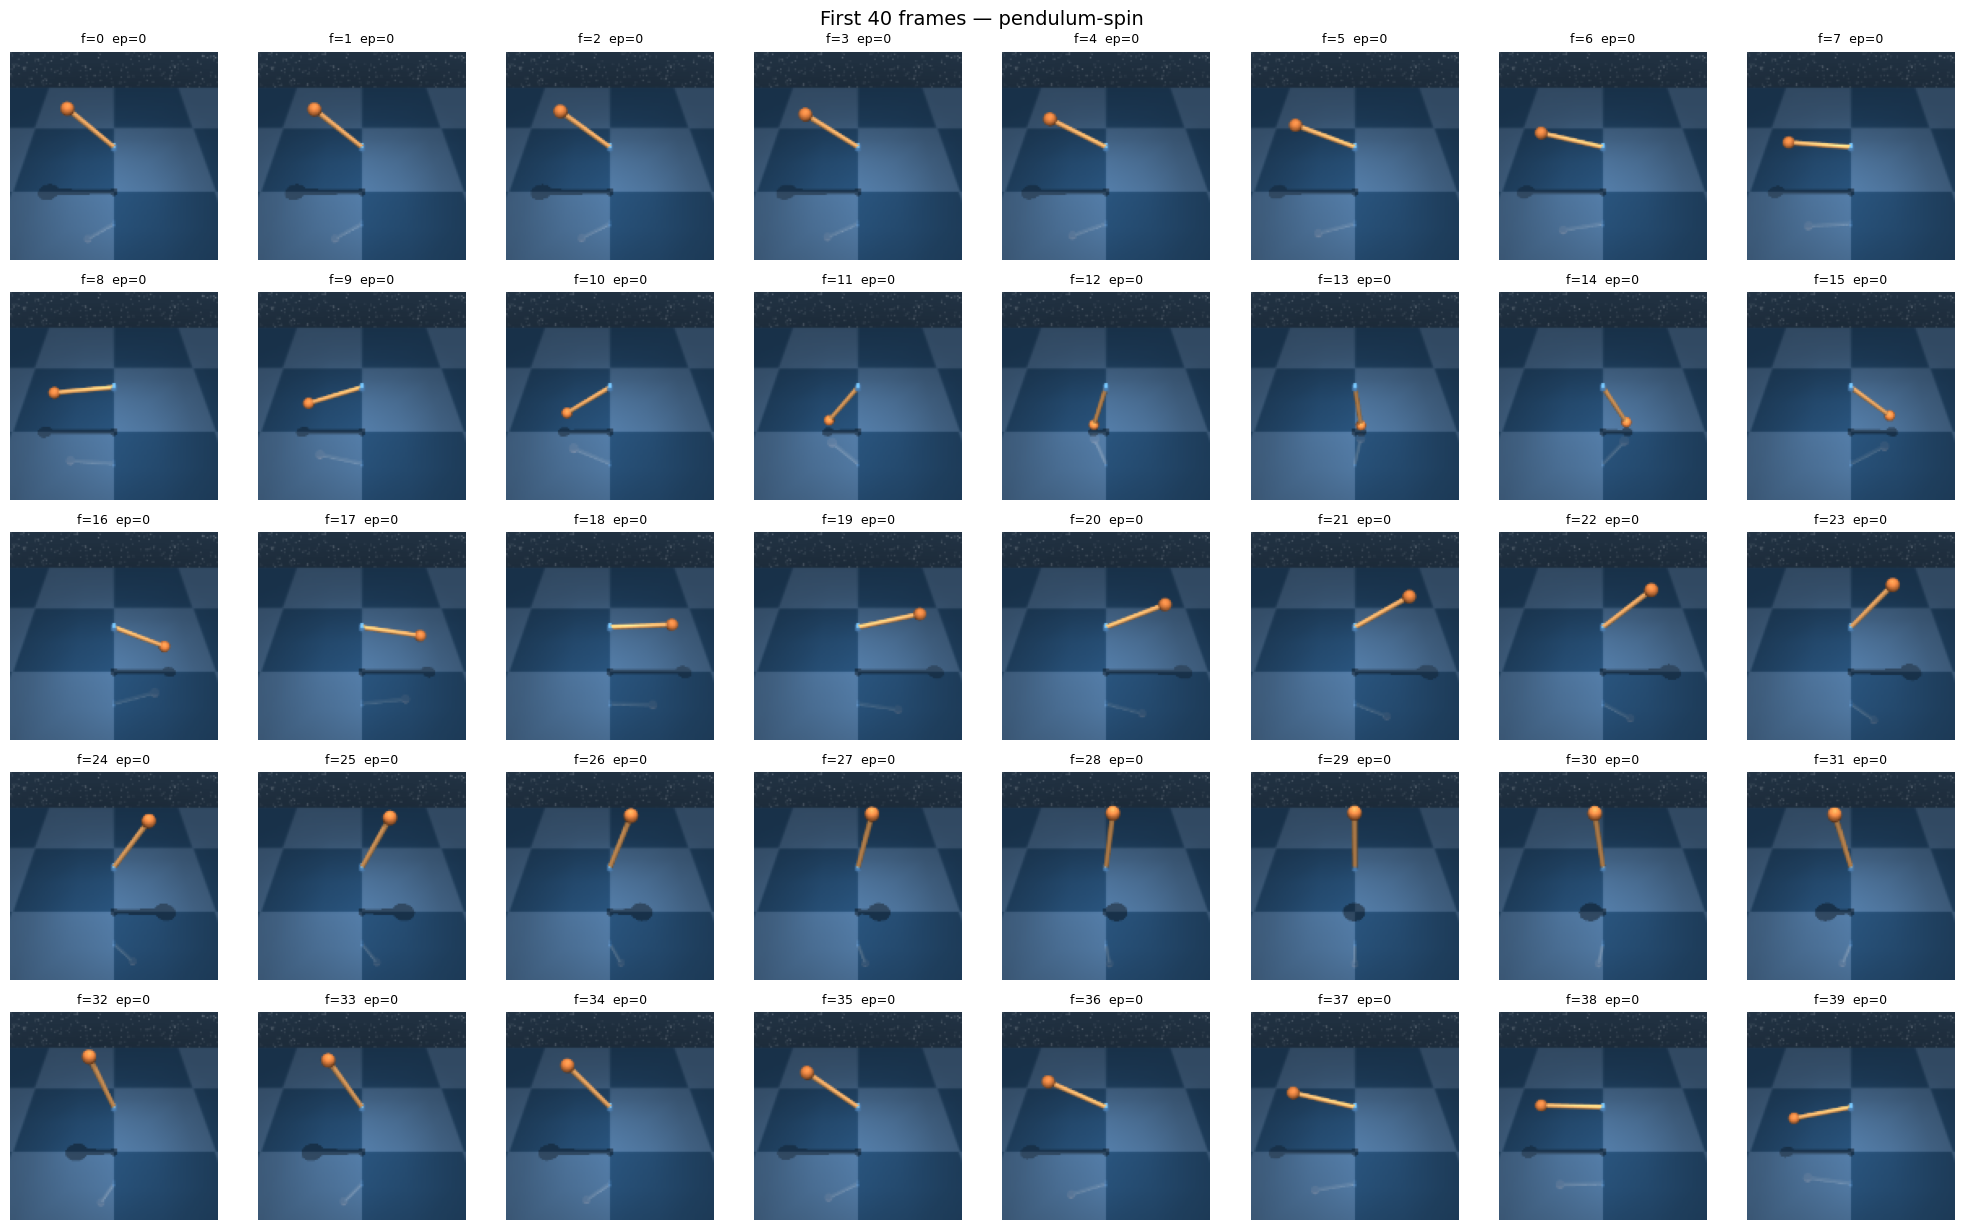

In [5]:
# Cell 3b: Quick-check first N frames

N_PREVIEW = 40  # number of frames to show
ncols = min(N_PREVIEW, 8)
nrows = (N_PREVIEW + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows))
axes = np.atleast_2d(axes)
for i in range(nrows * ncols):
    r, c = divmod(i, ncols)
    if i < N_PREVIEW:
        axes[r, c].imshow(frames[i].permute(1, 2, 0).clamp(0, 1).numpy())
        ep_id = episodes[i].item()
        axes[r, c].set_title(f"f={i}  ep={ep_id}", fontsize=9)
    axes[r, c].axis("off")
plt.suptitle(f"First {N_PREVIEW} frames — {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# Cell 4: Encode all frames -> latent features

@torch.inference_mode()
def encode_frames(encoder, frames, patch_size, device, batch_size=32):
    """Encode (N,3,H,W) frames -> (N, n_latents, d_bottleneck) latent features."""
    all_z = []
    for i in range(0, len(frames), batch_size):
        batch = frames[i:i+batch_size].to(device)
        # Add time dim: (B, 1, C, H, W)
        patches = temporal_patchify(batch.unsqueeze(1), patch_size)
        z, _ = encoder(patches)  # (B, 1, n_latents, d_bottleneck)
        all_z.append(z[:, 0].cpu())  # (B, n_latents, d_bottleneck)
    return torch.cat(all_z, 0)

latents = encode_frames(encoder, frames, patch, device)
print(f"Latent shape: {latents.shape}")  # (N, 16, 32)

# Flatten for analysis: (N, 512)
features = latents.reshape(latents.shape[0], -1).numpy()
print(f"Flattened features: {features.shape}")
print(f"Feature range: [{features.min():.3f}, {features.max():.3f}]")

Latent shape: torch.Size([40, 16, 32])
Flattened features: (40, 512)
Feature range: [-1.000, 1.000]


PSNR per frame: ['39.3', '40.1', '43.1', '41.6', '37.2', '36.9', '38.2', '41.3']
Mean PSNR: 39.7 dB


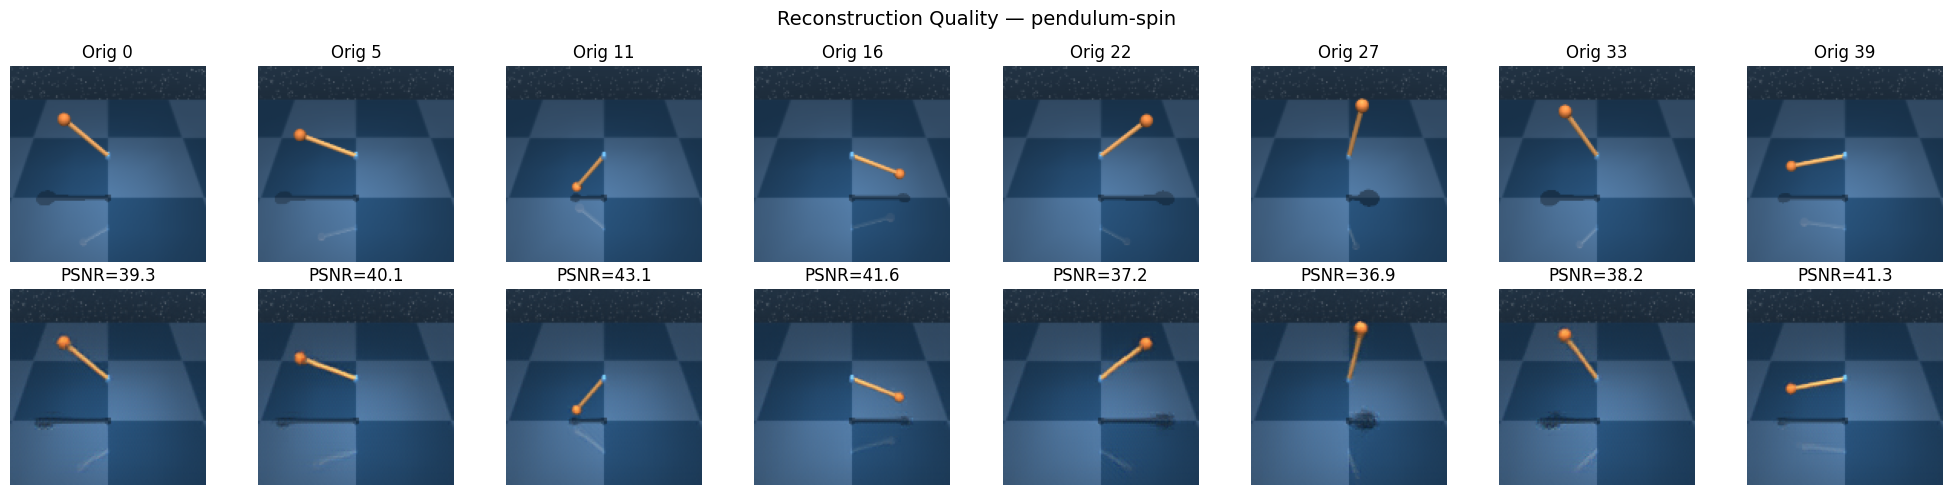

In [7]:
# Cell 5: Reconstruction sanity check

@torch.inference_mode()
def reconstruct_frames(encoder, decoder, frames, patch_size, H, W, C, device, indices=None):
    """Encode and decode selected frames. Returns originals and reconstructions."""
    if indices is None:
        indices = list(range(min(8, len(frames))))
    sel = frames[indices].to(device)
    patches = temporal_patchify(sel.unsqueeze(1), patch_size)  # (B,1,Np,Dp)
    z, _ = encoder(patches)
    recon_patches = decoder(z)  # (B,1,Np,Dp)
    recon = temporal_unpatchify(recon_patches, H, W, C, patch_size)  # (B,1,C,H,W)
    return sel.cpu(), recon[:, 0].cpu()

n_show = min(8, len(frames))
sample_idx = np.linspace(0, len(frames)-1, n_show, dtype=int).tolist()
orig, recon = reconstruct_frames(encoder, decoder, frames, patch, H, W, C, device, sample_idx)

# Compute PSNR
mse_per_frame = ((orig - recon) ** 2).mean(dim=(1,2,3))
psnr_per_frame = -10 * torch.log10(mse_per_frame)
print(f"PSNR per frame: {[f'{p:.1f}' for p in psnr_per_frame.tolist()]}")
print(f"Mean PSNR: {psnr_per_frame.mean():.1f} dB")

fig, axes = plt.subplots(2, n_show, figsize=(2.5 * n_show, 5))
if n_show == 1:
    axes = axes[:, np.newaxis]
for i in range(n_show):
    axes[0, i].imshow(orig[i].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, i].set_title(f"Orig {sample_idx[i]}")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, i].set_title(f"PSNR={psnr_per_frame[i]:.1f}")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.suptitle(f"Reconstruction Quality — {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

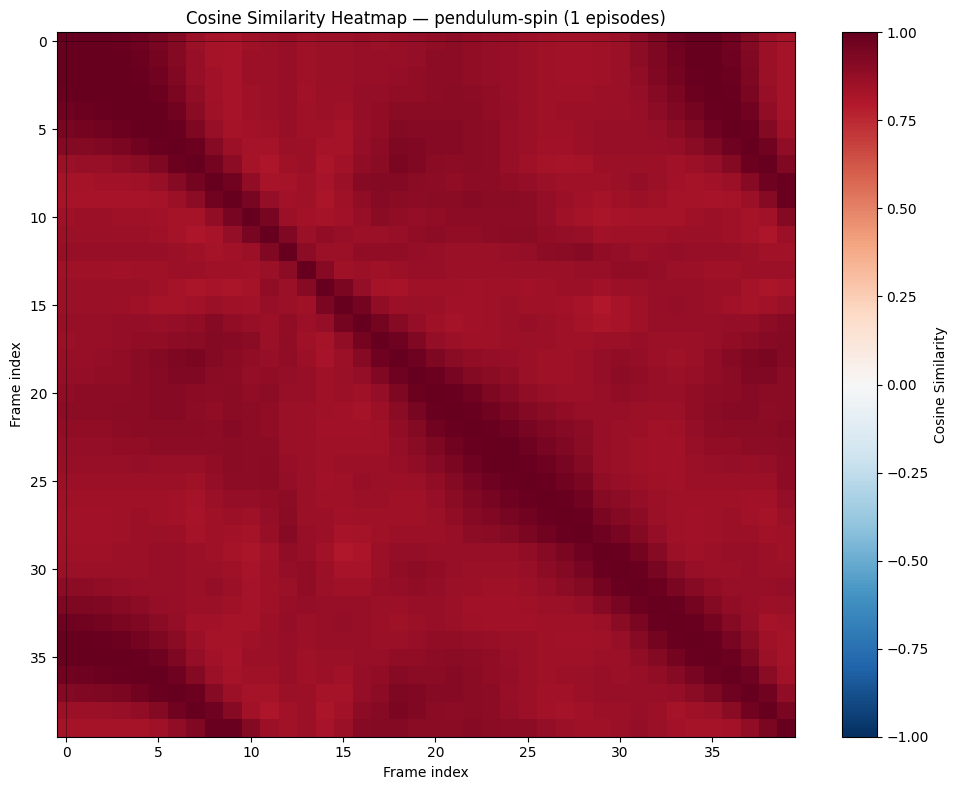

In [8]:
# Cell 6: Cosine similarity heatmap

from torch.nn.functional import cosine_similarity

feat_t = torch.from_numpy(features)  # (N, 512)
# Normalize for cosine sim
feat_norm = feat_t / feat_t.norm(dim=1, keepdim=True).clamp(min=1e-8)
cos_sim = feat_norm @ feat_norm.T  # (N, N)
cos_sim = cos_sim.numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cos_sim, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Cosine Similarity")

# Mark episode boundaries
for start, end in ep_boundaries:
    ax.axhline(y=start, color="black", linewidth=0.5, alpha=0.5)
    ax.axvline(x=start, color="black", linewidth=0.5, alpha=0.5)

ax.set_xlabel("Frame index")
ax.set_ylabel("Frame index")
ax.set_title(f"Cosine Similarity Heatmap — {TASK} ({len(ep_boundaries)} episodes)")
plt.tight_layout()
plt.show()

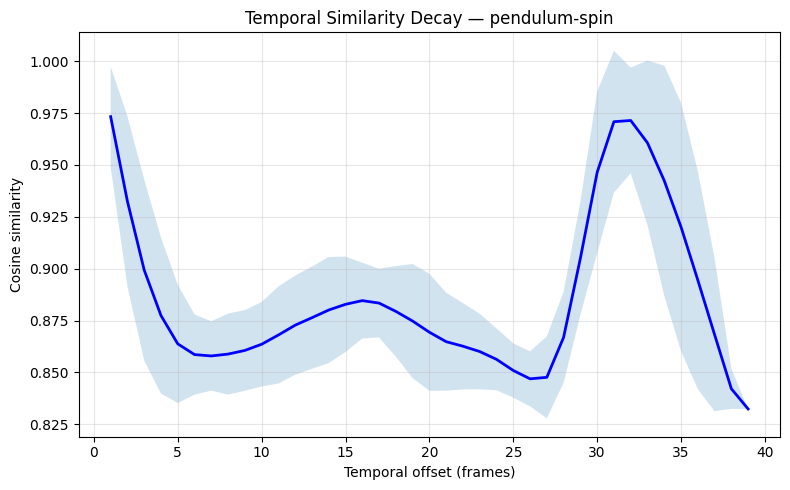

In [9]:
# Cell 7: Temporal similarity decay curve

max_offset = 100
sim_by_offset = {k: [] for k in range(1, max_offset + 1)}

for start, end in ep_boundaries:
    ep_feat = feat_norm[start:end]  # (L, 512)
    L = ep_feat.shape[0]
    for k in range(1, min(max_offset + 1, L)):
        sims = (ep_feat[:-k] * ep_feat[k:]).sum(dim=1)  # cosine sim
        sim_by_offset[k].extend(sims.tolist())

offsets = list(range(1, max_offset + 1))
mean_sims = [np.mean(sim_by_offset[k]) for k in offsets if sim_by_offset[k]]
std_sims = [np.std(sim_by_offset[k]) for k in offsets if sim_by_offset[k]]
offsets = offsets[:len(mean_sims)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(offsets, mean_sims, "b-", linewidth=2)
ax.fill_between(offsets,
                np.array(mean_sims) - np.array(std_sims),
                np.array(mean_sims) + np.array(std_sims),
                alpha=0.2)
ax.set_xlabel("Temporal offset (frames)")
ax.set_ylabel("Cosine similarity")
ax.set_title(f"Temporal Similarity Decay — {TASK}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

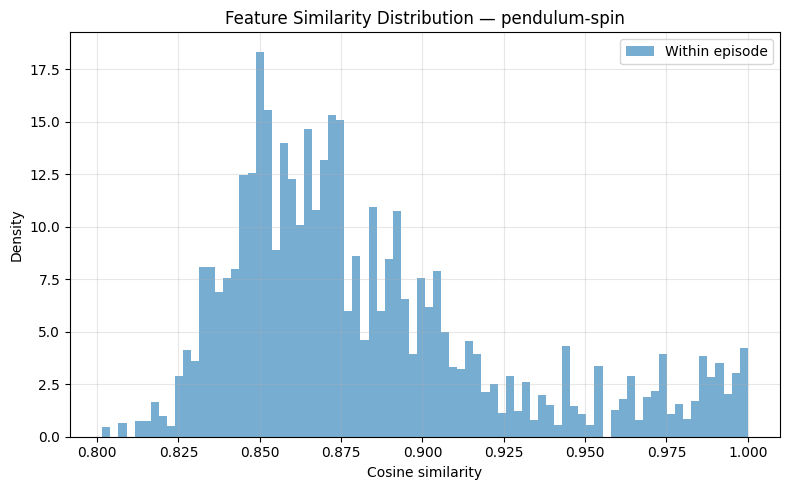

Within-episode:  mean=0.883, std=0.043


In [10]:
# Cell 8: Within-episode vs across-episode similarity distributions

n_samples = 10000
rng = np.random.default_rng(42)

within_sims = []
across_sims = []

# Within-episode pairs
for _ in range(n_samples):
    ep_idx = rng.integers(len(ep_boundaries))
    s, e = ep_boundaries[ep_idx]
    if e - s < 2:
        continue
    i, j = rng.choice(e - s, size=2, replace=False) + s
    within_sims.append(cos_sim[i, j])

# # Across-episode pairs
# for _ in range(n_samples):
#     ep1, ep2 = rng.choice(len(ep_boundaries), size=2, replace=False)
#     s1, e1 = ep_boundaries[ep1]
#     s2, e2 = ep_boundaries[ep2]
#     i = rng.integers(s1, e1)
#     j = rng.integers(s2, e2)
#     across_sims.append(cos_sim[i, j])

# fig, ax = plt.subplots(figsize=(8, 5))
# ax.hist(within_sims, bins=80, alpha=0.6, density=True, label="Within episode")
# ax.hist(across_sims, bins=80, alpha=0.6, density=True, label="Across episodes")
# ax.set_xlabel("Cosine similarity")
# ax.set_ylabel("Density")
# ax.set_title(f"Feature Similarity Distribution — {TASK}")
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print(f"Within-episode:  mean={np.mean(within_sims):.3f}, std={np.std(within_sims):.3f}")
# print(f"Across-episode:  mean={np.mean(across_sims):.3f}, std={np.std(across_sims):.3f}")
if len(ep_boundaries) >= 2:
    for _ in range(n_samples):
        ep1, ep2 = rng.choice(len(ep_boundaries), size=2, replace=False)
        s1, e1 = ep_boundaries[ep1]
        s2, e2 = ep_boundaries[ep2]
        i = rng.integers(s1, e1)
        j = rng.integers(s2, e2)
        across_sims.append(cos_sim[i, j])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(within_sims, bins=80, alpha=0.6, density=True, label="Within episode")
if across_sims:
    ax.hist(across_sims, bins=80, alpha=0.6, density=True, label="Across episodes")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title(f"Feature Similarity Distribution — {TASK}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Within-episode:  mean={np.mean(within_sims):.3f}, std={np.std(within_sims):.3f}")
if across_sims:
    print(f"Across-episode:  mean={np.mean(across_sims):.3f}, std={np.std(across_sims):.3f}")

In [11]:
# Cell 9: Dimension reduction & t-SNE visualization
# Adapted from analyzer.py get_projection() (lines 769-819)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA first if feature dim > N samples (t-SNE needs N > n_components)
n_samples, n_feat = features.shape
if n_feat > n_samples:
    n_pca = max(2, n_samples - 1)
    pca_input = PCA(n_components=n_pca).fit_transform(features)
    print(f"PCA reduced: {features.shape} -> {pca_input.shape} (N < feat_dim)")
elif n_feat > 50:
    pca_input = PCA(n_components=50).fit_transform(features)
    print(f"PCA reduced: {features.shape} -> {pca_input.shape}")
else:
    pca_input = features
    print(f"Skipping PCA (feat_dim={n_feat} already small)")

# t-SNE -> 2 dims (lower perplexity for small N)
perp = min(30, max(2, n_samples // 4))
tsne = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate="auto",
    init="random" if pca_input.shape[1] < 2 else "pca",
    max_iter=2000,
    metric="euclidean",
    random_state=0,
    verbose=1,
)
Y = tsne.fit_transform(pca_input)
print(f"t-SNE done: {Y.shape} (perplexity={perp})")

PCA reduced: (40, 512) -> (40, 39) (N < feat_dim)
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 40 samples in 0.000s...
[t-SNE] Computed neighbors for 40 samples in 0.090s...
[t-SNE] Computed conditional probabilities for sample 40 / 40
[t-SNE] Mean sigma: 4.721320
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.829071
[t-SNE] KL divergence after 1150 iterations: 0.201875
t-SNE done: (40, 2) (perplexity=10)


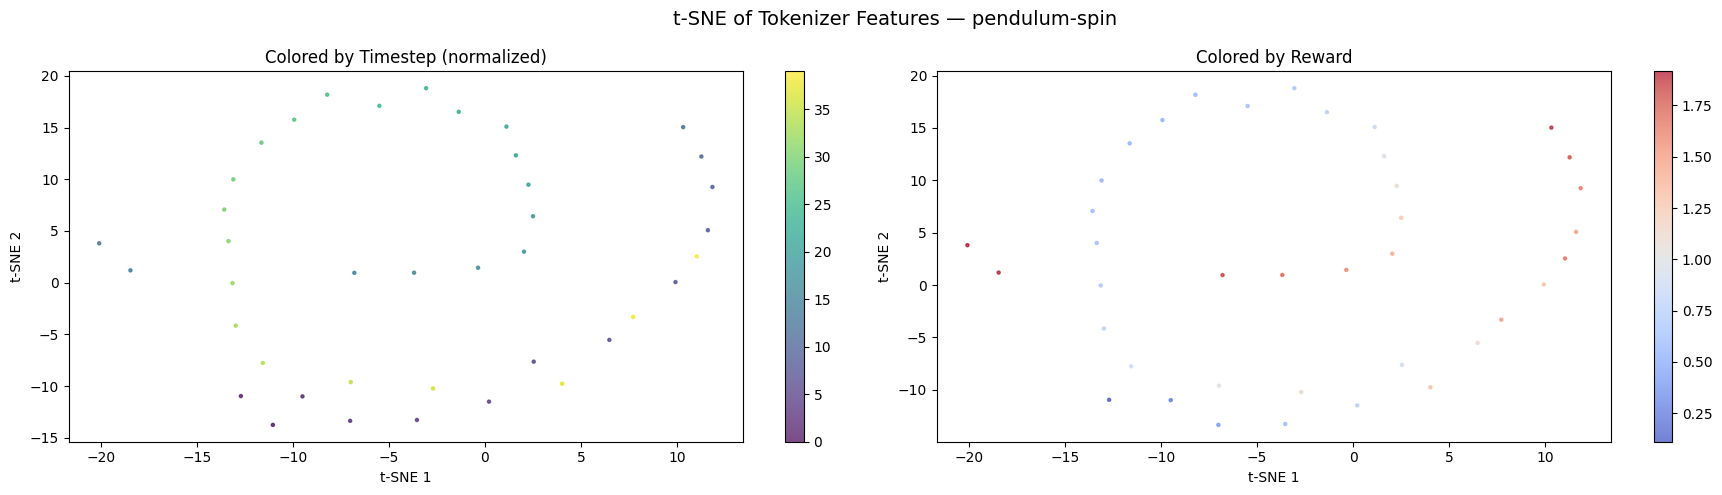

In [12]:
# t-SNE colored by episode, timestep, and reward

pt_size = max(3, 200 // max(len(features), 1))  # larger dots for fewer points
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# # Color by episode index
# ep_ids = episodes.cpu().numpy()
# sc0 = axes[0].scatter(Y[:, 0], Y[:, 1], c=ep_ids, cmap="tab20", s=pt_size, alpha=0.7, rasterized=True)
# axes[0].set_title("Colored by Episode")
# plt.colorbar(sc0, ax=axes[0])

# Color by timestep within episode
timesteps = np.zeros(len(features))
for start, end in ep_boundaries:
    ep_len = end - start
    timesteps[start:end] = np.arange(ep_len) #/ max(ep_len - 1, 1)
sc1 = axes[0].scatter(Y[:, 0], Y[:, 1], c=timesteps, cmap="viridis", s=pt_size, alpha=0.7, rasterized=True)
axes[0].set_title("Colored by Timestep (normalized)")
plt.colorbar(sc1, ax=axes[0])

# Color by reward
rew_np = rewards.cpu().numpy()
sc2 = axes[1].scatter(Y[:, 0], Y[:, 1], c=rew_np, cmap="coolwarm", s=pt_size, alpha=0.7, rasterized=True)
axes[1].set_title("Colored by Reward")
plt.colorbar(sc2, ax=axes[1])

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle(f"t-SNE of Tokenizer Features — {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

NN scores (k=20): mean=72.6066, std=17.6459
Min (densest): 47.5254, Max (most isolated): 110.0264


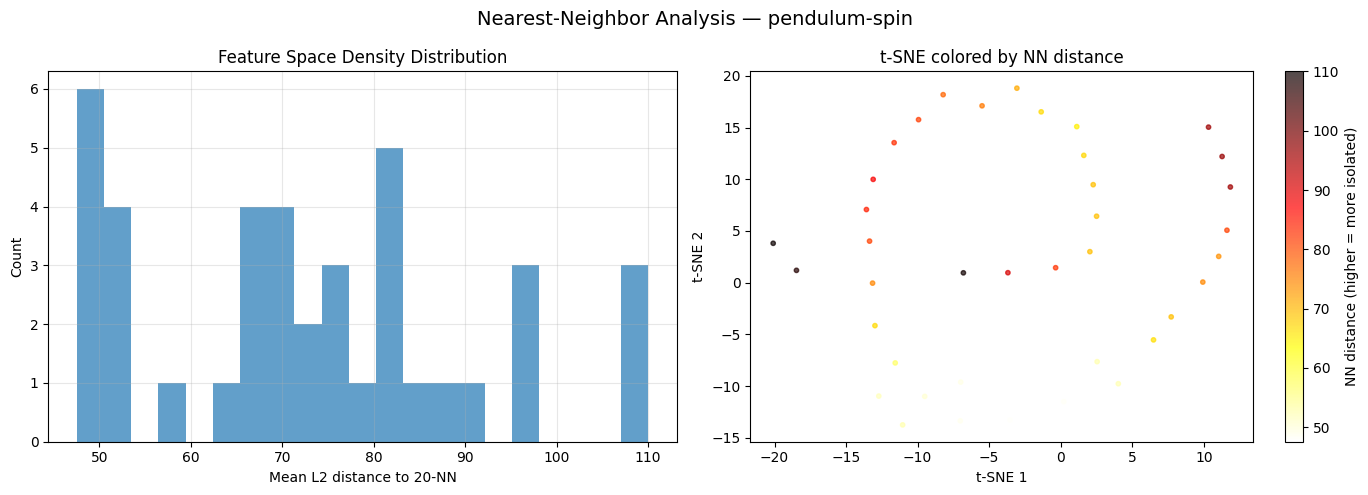

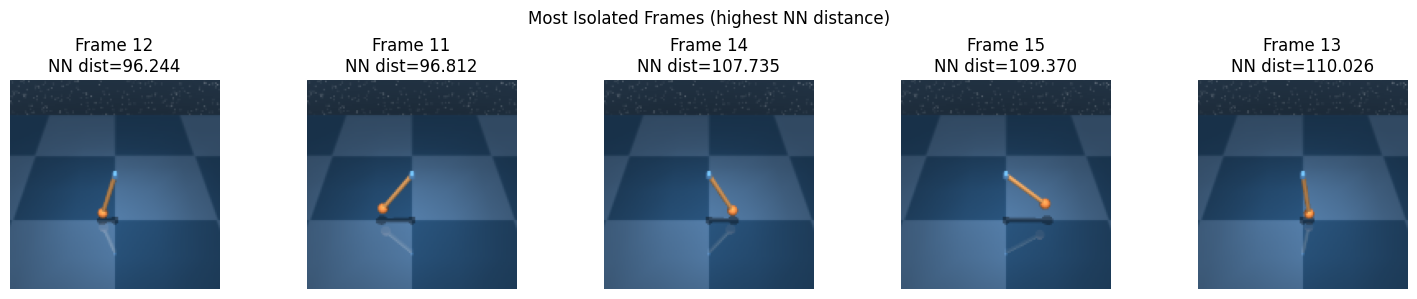

In [13]:
# Cell 10: FAISS nearest-neighbor analysis
# Adapted from analyzer.py (lines 903-917)

import faiss

features_f32 = features.astype(np.float32)
index = faiss.IndexFlatL2(features_f32.shape[1])
index.add(features_f32)

k_nn = min(20, len(features_f32) - 1)
distances, nn_indices = index.search(features_f32, k_nn)
nn_scores = distances.mean(axis=-1)  # avg L2 distance to k-NN

print(f"NN scores (k={k_nn}): mean={nn_scores.mean():.4f}, std={nn_scores.std():.4f}")
print(f"Min (densest): {nn_scores.min():.4f}, Max (most isolated): {nn_scores.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of NN distances
axes[0].hist(nn_scores, bins=min(80, len(nn_scores) // 2 + 1), alpha=0.7)
axes[0].set_xlabel(f"Mean L2 distance to {k_nn}-NN")
axes[0].set_ylabel("Count")
axes[0].set_title("Feature Space Density Distribution")
axes[0].grid(True, alpha=0.3)

# t-SNE colored by NN score (outlier detection)
sc = axes[1].scatter(Y[:, 0], Y[:, 1], c=nn_scores, cmap="hot_r", s=10, alpha=0.7, rasterized=True)
plt.colorbar(sc, ax=axes[1], label="NN distance (higher = more isolated)")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].set_title("t-SNE colored by NN distance")

plt.suptitle(f"Nearest-Neighbor Analysis — {TASK}", fontsize=14)
plt.tight_layout()
plt.show()

# Show most isolated frames
n_outliers = min(5, len(frames))
top_outliers = np.argsort(nn_scores)[-n_outliers:]
fig, axes = plt.subplots(1, n_outliers, figsize=(3 * n_outliers, 3))
if n_outliers == 1:
    axes = [axes]
for i, idx in enumerate(top_outliers):
    axes[i].imshow(frames[idx].permute(1, 2, 0).numpy())
    axes[i].set_title(f"Frame {idx}\nNN dist={nn_scores[idx]:.3f}")
    axes[i].axis("off")
plt.suptitle("Most Isolated Frames (highest NN distance)")
plt.tight_layout()
plt.show()